In [1]:
# Core
import os
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# Plot settings
import matplotlib
%matplotlib inline

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
#plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.dpi'] = 300

# matplotlib.rc('xtick', labelsize=10, direction='out')
# matplotlib.rc('ytick', labelsize=10, direction='out')
matplotlib.rc('xtick', labelsize=12, direction='out')
matplotlib.rc('ytick', labelsize=12, direction='out')

#### **FIGURE 1**

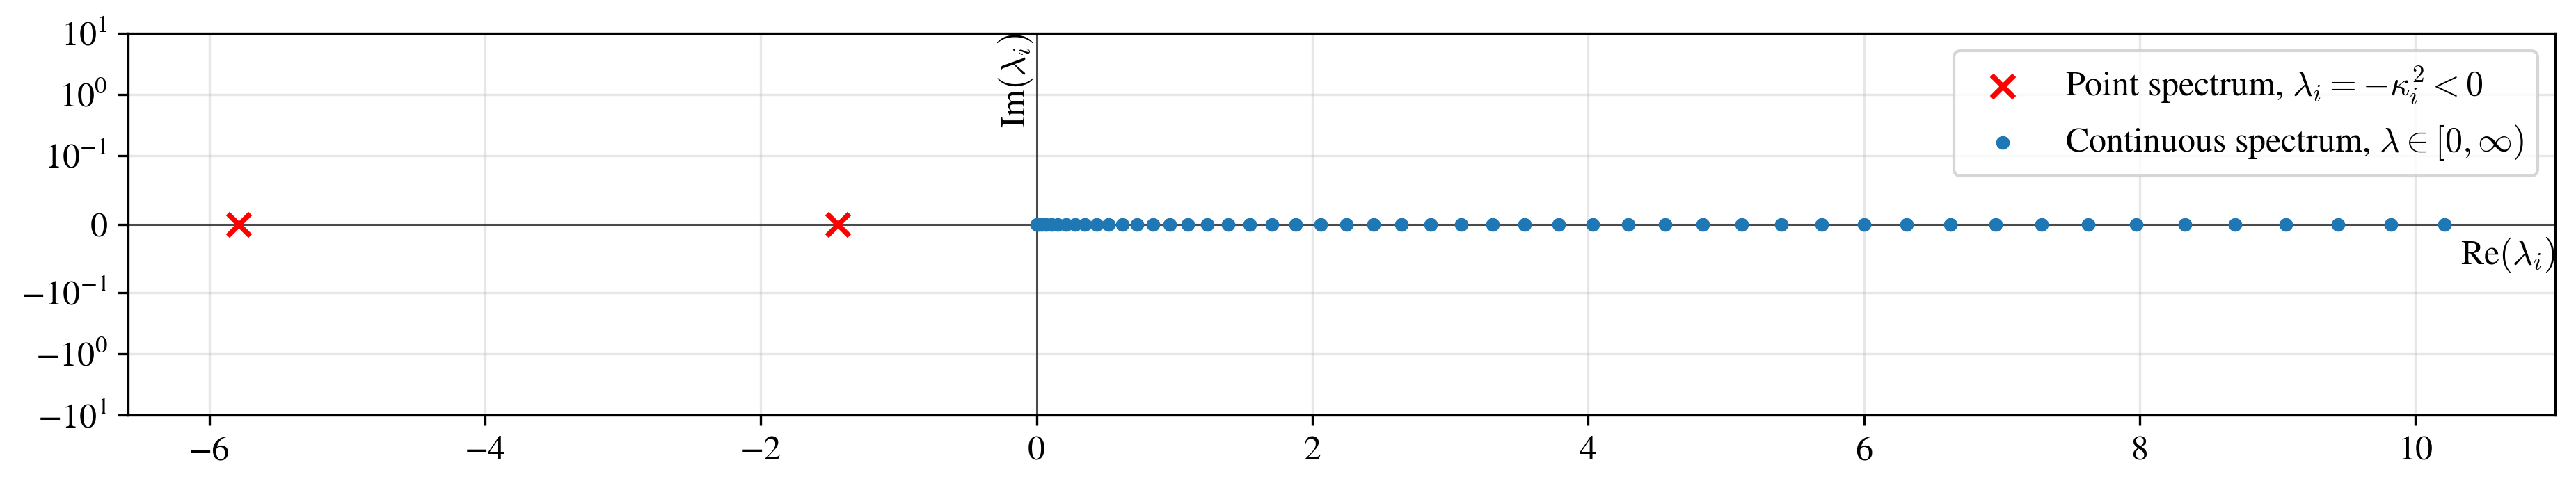

In [78]:
# First row --> spectrum of the clean data
from netCDF4 import Dataset
from compute_scattering_data import scattering_data, scattering_data_sequence, IST_reflectionless

noise = 0.20
sub_x = 3
snapshot = 0
num_continuous = 50
min_kappa = 0.5

with Dataset("outputs/kdv_soliton_collision_v0.nc") as nc:
    x = nc["x"][:].data
    t = nc["t"][:].data
    U_star = nc["u"][:].data

x_sub = x[::sub_x]
U_star_sub = U_star[:, ::sub_x]

data_star = scattering_data(x_sub, U_star_sub[snapshot], min_kappa=min_kappa, auto_compute=False)
data_star.compute_spectrum()
point_spectrum = data_star.point_spectrum
continuous_spectrum = data_star.continuous_spectrum[:num_continuous]

fig, ax = plt.subplots(figsize=(12.5, 2.5))
ax.axhline(0, color="black", lw=0.7, alpha=0.7)
ax.axvline(0, color="black", lw=0.7, alpha=0.7)
ax.scatter(point_spectrum.real, point_spectrum.imag, color="red", marker="x", s=60, lw=1.8, label=r"Point spectrum, $\lambda_i = -\kappa_i^2 < 0$", zorder=10)
ax.scatter(continuous_spectrum.real, continuous_spectrum.imag, color="C0", marker=".", s=55, label=r"Continuous spectrum, $\lambda \in [0,\infty)$", zorder=10)
ax.set_yscale("symlog", linthresh=0.1)
ax.set_ylim(-10, 10)
ax.set_xlabel(r"Re$(\lambda_i)$", loc="right", labelpad=-80)
ax.set_ylabel(r"Im$(\lambda_i)$", loc="top", labelpad=-350)
ax.grid(True, linestyle="-", alpha=0.3)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

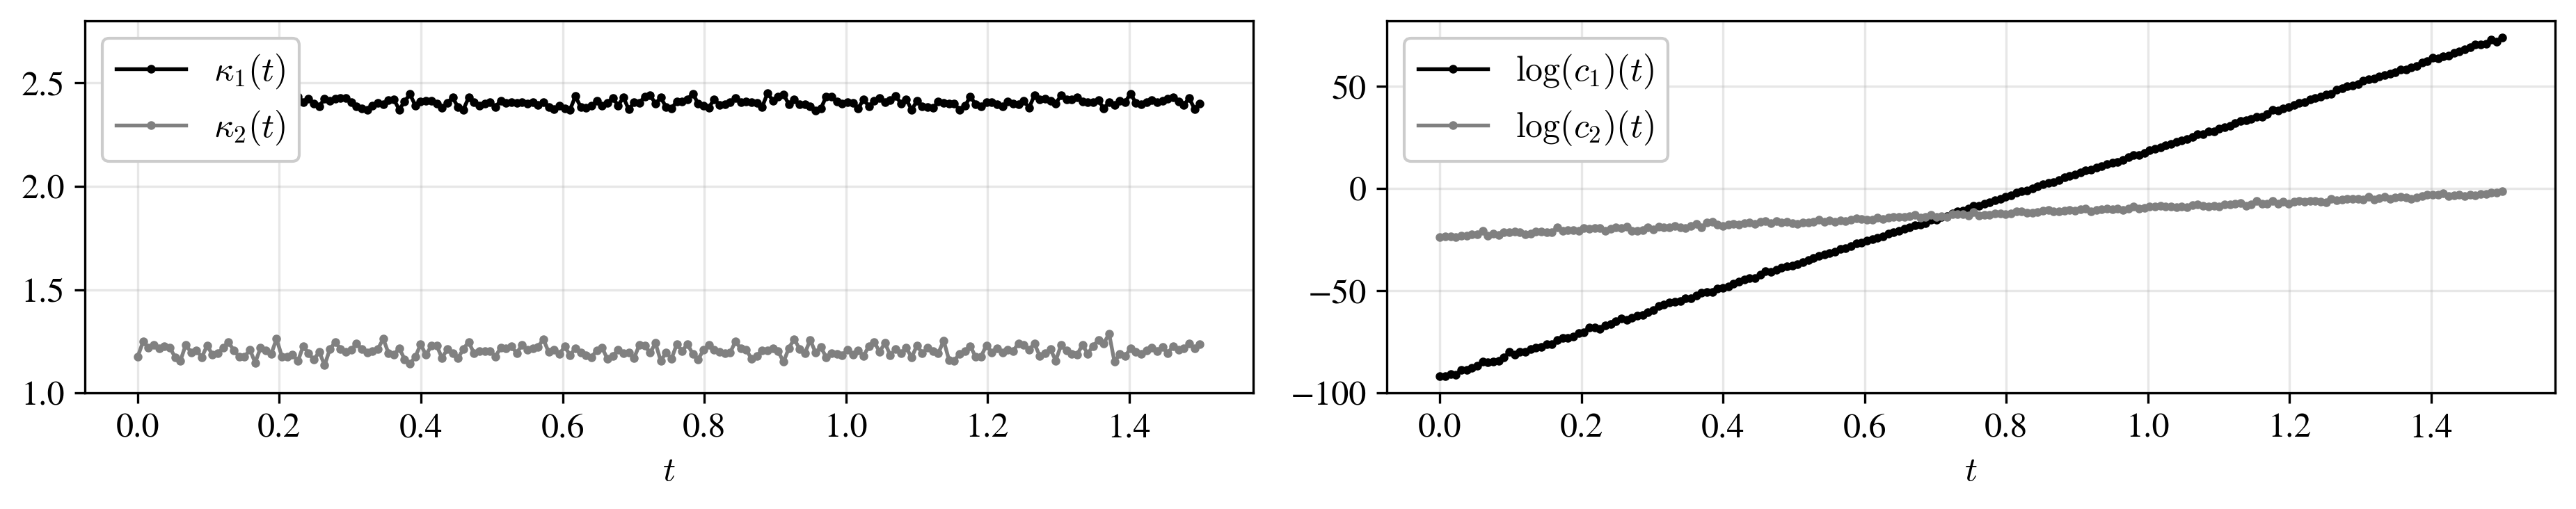

In [79]:
# Second row --> numerically computed scattering data
from netCDF4 import Dataset
from compute_scattering_data import scattering_data_sequence

noise = 0.20
sub_x = 3
min_kappa = 0.5
seed = 0

with Dataset("outputs/kdv_soliton_collision_v0.nc") as nc:
    x = nc["x"][:].data
    t = nc["t"][:].data
    U_star = nc["u"][:].data

rng = np.random.default_rng(seed)
eta = rng.normal(size=U_star.shape)
eta *= noise*np.linalg.norm(U_star)/np.linalg.norm(eta)
U = U_star + eta

x_sub = x[::sub_x]
U_sub = U[:, ::sub_x]
U_star_sub = U_star[:, ::sub_x]

collision_data = scattering_data_sequence(x_sub, U_sub, t_grid=t, min_kappa=min_kappa)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 2.6))

for i in range(max(collision_data.n)):
    ti = []
    ki = []
    logci = []
    for j,sd in enumerate(collision_data.snapshots):
        if len(sd.kappas) > i:
            ti.append(collision_data.t[j])
            ki.append(np.real(sd.kappas[i]))
            logci.append(np.real(sd.log_cs[i]))
    if i == 0:
        axes[0].plot(ti, ki, ".-", color="k", ms=4, lw=1.3, label=rf"$\kappa_{i+1}(t)$")
        axes[1].plot(ti, logci, ".-", color="k", ms=4, lw=1.3, label=rf"$\log(c_{i+1})(t)$")
    else:
        axes[0].plot(ti, ki, ".-", color="gray", ms=4, lw=1.3, label=rf"$\kappa_{i+1}(t)$")
        axes[1].plot(ti, logci, ".-", color="gray", ms=4, lw=1.3, label=rf"$\log(c_{i+1})(t)$")

axes[0].set_xlabel(r"$t$")
axes[0].set_ylim([1.0, 2.8])
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left", framealpha=1)

axes[1].set_xlabel(r"$t$")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left", framealpha=1)

plt.tight_layout()
plt.show()

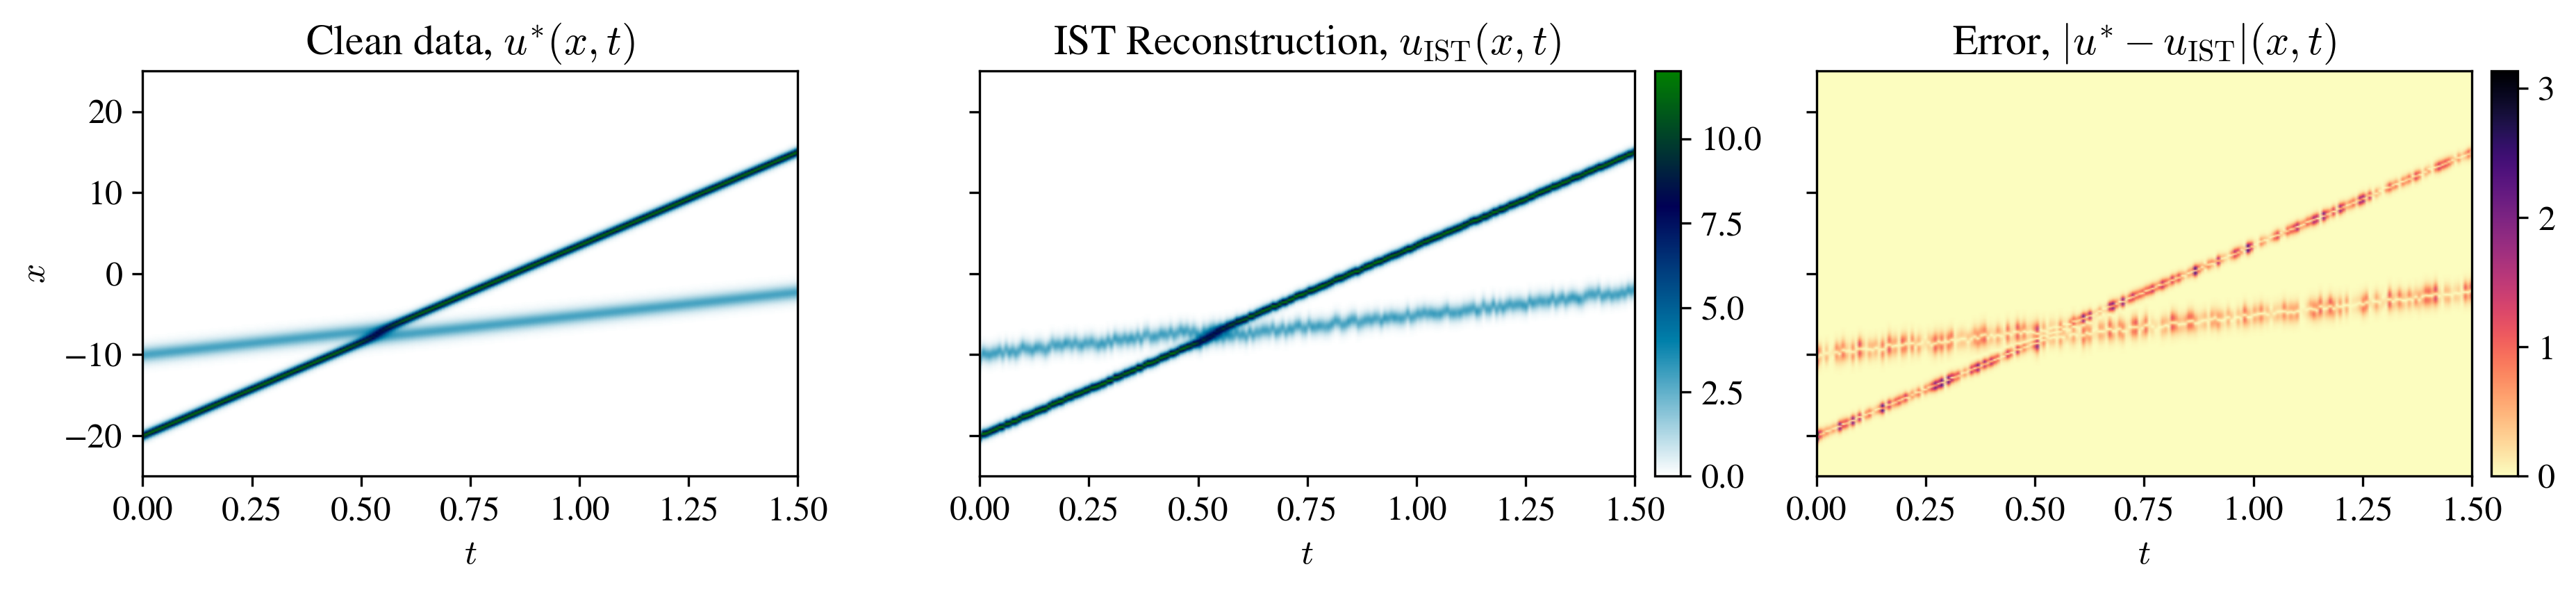

In [94]:
# Third row --> IST reconstruction
from compute_scattering_data import IST_reflectionless

U_ist = np.asarray([IST_reflectionless(x_sub, sd.kappas, sd.cs) for sd in collision_data.snapshots])

vmin = min(U_star_sub.min(), U_ist.min())
vmax = max(U_star_sub.max(), U_ist.max())

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.0), sharex=True, sharey=True)
#fig.subplots_adjust(wspace=0.15)
fig.subplots_adjust(wspace=0.2)

axes[0].pcolormesh(t, x_sub, U_star_sub.T, cmap="ocean_r", shading="gouraud", vmin=vmin, vmax=vmax)
axes[0].set_title(r"Clean data, $u^{*}(x,t)$")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$x$")

pc1 = axes[1].pcolormesh(t, x_sub, U_ist.T, cmap="ocean_r", shading="gouraud", vmin=vmin, vmax=vmax)
axes[1].set_title(r"IST Reconstruction, $u_{\rm IST}(x,t)$")
axes[1].set_xlabel(r"$t$")
cax1 = axes[1].inset_axes([1.03, 0, 0.04, 1])
fig.colorbar(pc1, cax=cax1)

pc2 = axes[2].pcolormesh(t, x_sub, np.abs(U_star_sub - U_ist).T, cmap="magma_r", shading="gouraud")
axes[2].set_title(r"Error, $|u^{*} - u_{\rm IST}|(x,t)$")
axes[2].set_xlabel(r"$t$")
cax2 = axes[2].inset_axes([1.03, 0, 0.04, 1])
fig.colorbar(pc2, cax=cax2)

plt.tight_layout()
plt.show()

#### **FIGURE 2**

In [3]:
# Load clean/perturbed data, add noise, and track perturbed soliton peaks.
# The v0 perturbed runs share epsilon=6, mu=1, soliton_velocity, and IC type with their
# unperturbed counterparts (only eta=0.2 differs), so their initial kappas match.
from netCDF4 import Dataset
from scipy.signal import find_peaks

noise = 0.20    # noise ratio added to the clean (unperturbed) heatmap/snapshot data only
seed = 0

single_path              = "outputs/kdv_single_soliton_v0.nc"
collision_path           = "outputs/kdv_soliton_collision_v0.nc"
single_perturbed_path    = "outputs/kdv_single_soliton_perturbed_v0.nc"
collision_perturbed_path = "outputs/kdv_soliton_collision_perturbed_v0.nc"


def load_kdv(path):
    with Dataset(path) as nc:
        return nc["x"][:].data.astype(float), nc["t"][:].data.astype(float), nc["u"][:].data.astype(float)


def add_noise(U_star, noise, seed):
    rng = np.random.default_rng(seed)
    eta = rng.normal(size=U_star.shape)
    if noise > 0:
        eta *= noise*np.linalg.norm(U_star)/np.linalg.norm(eta)
    return U_star + eta


def subpixel_peak(u_row, x_grid, idx):
    x_peak = x_grid[idx]
    if 0 < idx < len(x_grid) - 1:
        y_l, y_c, y_r = u_row[idx-1], u_row[idx], u_row[idx+1]
        denom = y_l - 2*y_c + y_r
        if denom != 0:
            x_peak += 0.5*(y_l - y_r)/denom*(x_grid[1] - x_grid[0])
    return x_peak


def single_peak_trajectory(x_grid, u):
    return np.array([subpixel_peak(u[j], x_grid, np.argmax(u[j])) for j in range(len(u))])


def collision_peak_trajectories(x_grid, u, prominence=0.25, distance=40):
    p1 = np.full(len(u), np.nan)
    p2 = np.full(len(u), np.nan)
    for j in range(len(u)):
        u_j = u[j]
        peaks, _ = find_peaks(u_j, prominence=prominence, distance=distance)
        if len(peaks) == 0:
            peaks = np.array([np.argmax(u_j)])
        peaks = peaks[np.argsort(u_j[peaks])[::-1]]   # order by amplitude (n=1 = tallest/fast soliton)
        p1[j] = subpixel_peak(u_j, x_grid, peaks[0])
        if len(peaks) > 1:
            p2[j] = subpixel_peak(u_j, x_grid, peaks[1])
    return p1, p2


def fill_nans(y):    # linearly interpolate n=2 across the merge (single-peak) window
    good = np.isfinite(y)
    return np.interp(np.arange(len(y)), np.flatnonzero(good), y[good])


x_single, t_single, u_single       = load_kdv(single_path)
x_coll, t_coll, u_coll             = load_kdv(collision_path)
x_single_p, t_single_p, u_single_p = load_kdv(single_perturbed_path)
x_coll_p, t_coll_p, u_coll_p       = load_kdv(collision_perturbed_path)

u_single_noisy = add_noise(u_single, noise, seed)
u_coll_noisy   = add_noise(u_coll, noise, seed)

single_peak_x = single_peak_trajectory(x_single_p, u_single_p)
coll_peak_x1, coll_peak_x2 = collision_peak_trajectories(x_coll_p, u_coll_p)
coll_peak_x2 = fill_nans(coll_peak_x2)

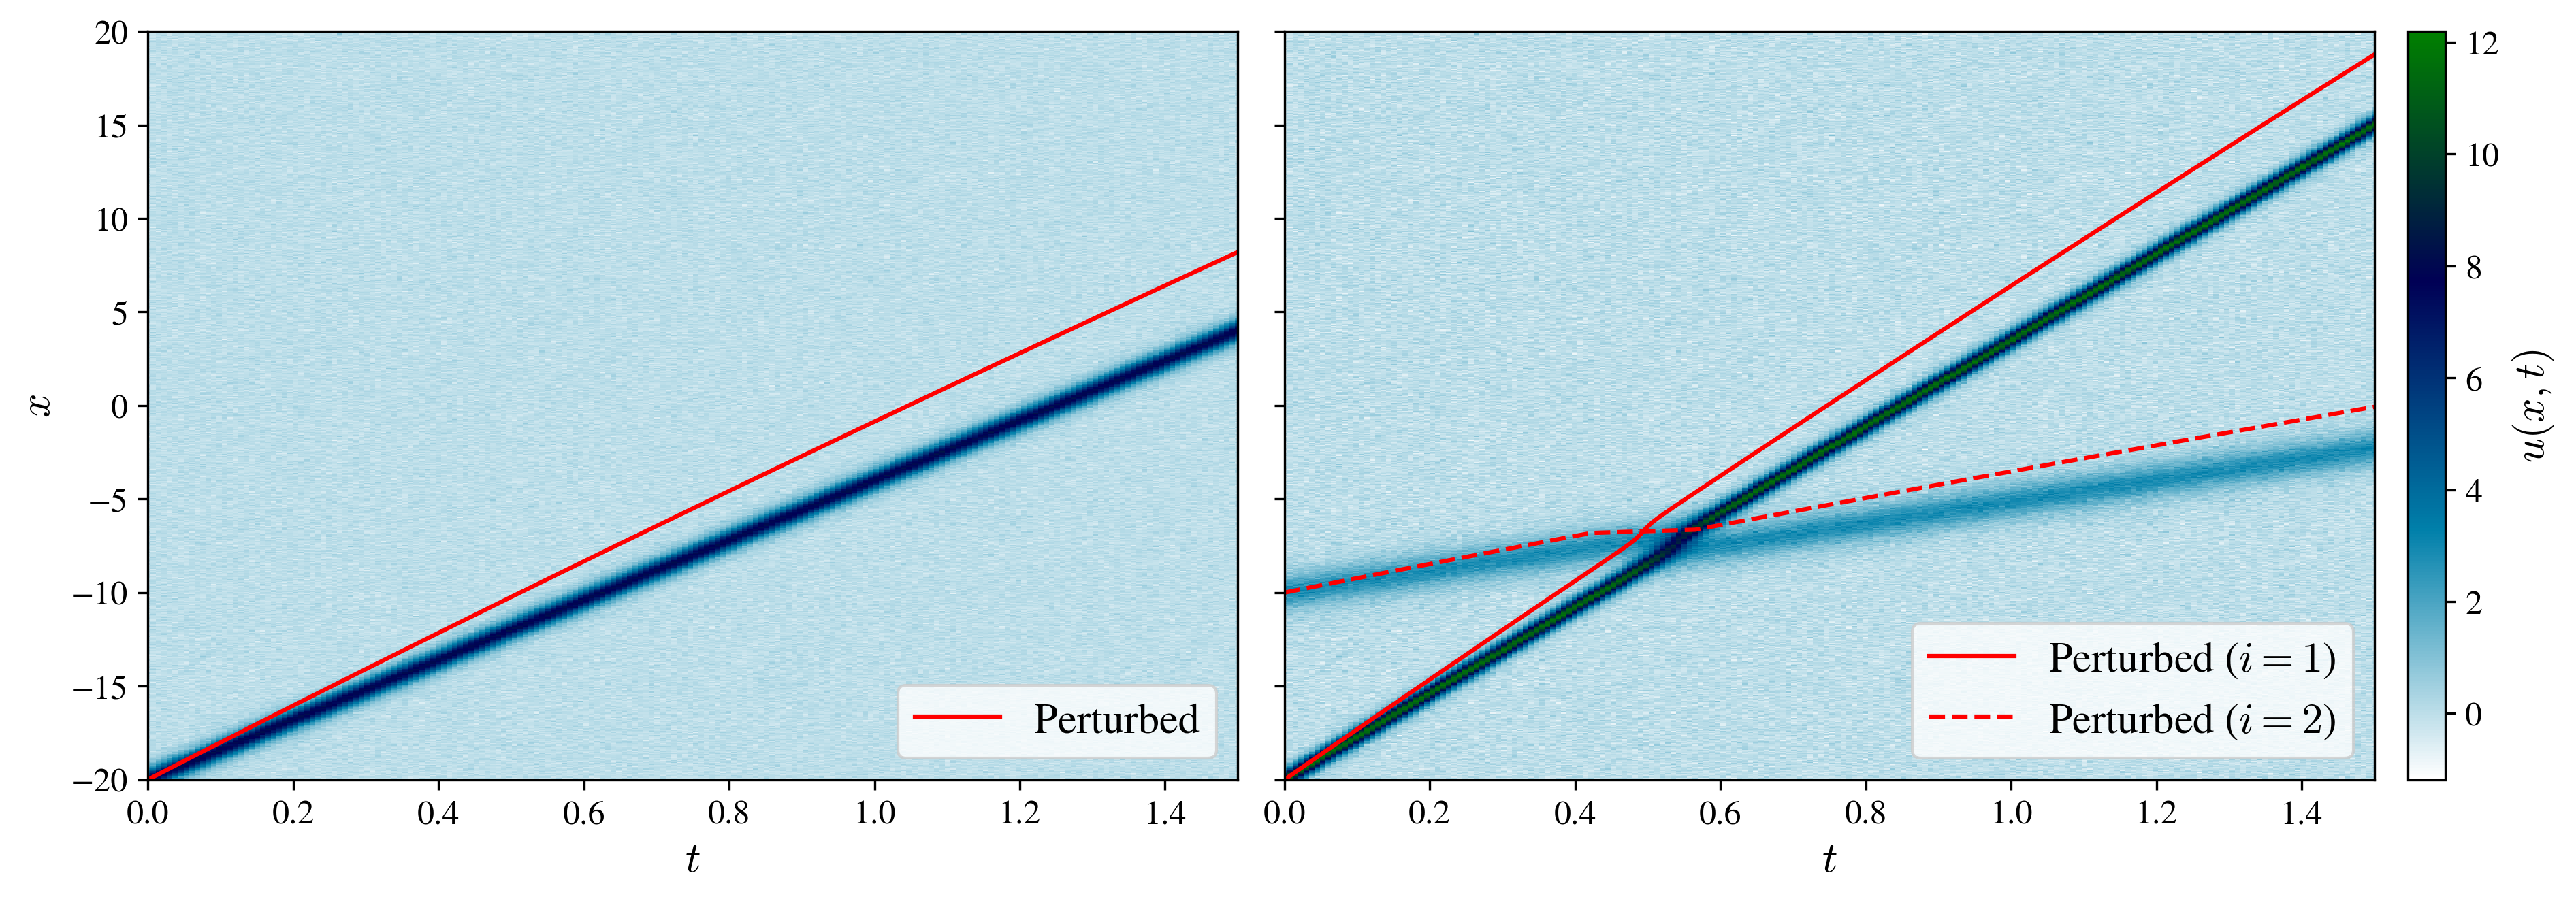

In [29]:
# Heatmaps of the unperturbed single soliton (left) and collision (right), with perturbed peak overlays
vmin = min(u_single_noisy.min(), u_coll_noisy.min())
vmax = max(u_single_noisy.max(), u_coll_noisy.max())

cmap = "ocean_r"
ylim = (-20, 20)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3), sharey=True, constrained_layout=True)

axes[0].pcolormesh(t_single, x_single, u_single_noisy.T, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
axes[0].plot(t_single_p, single_peak_x, "-", color="red", lw=1.5, label=r"Perturbed")
axes[0].set_xlabel(r"$t$", fontsize=15)
axes[0].set_ylabel(r"$x$", fontsize=15)
axes[0].set_xlim(t_single[0], t_single[-1])
axes[0].set_ylim(*ylim)
axes[0].legend(fontsize=15, loc="lower right")

mesh = axes[1].pcolormesh(t_coll, x_coll, u_coll_noisy.T, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
axes[1].plot(t_coll_p, coll_peak_x1, "-", color="red", lw=1.5, label=r"Perturbed ($i=1$)")
axes[1].plot(t_coll_p, coll_peak_x2, "--", color="red", lw=1.5, label=r"Perturbed ($i=2$)")
axes[1].set_xlabel(r"$t$", fontsize=15)
axes[1].set_xlim(t_coll[0], t_coll[-1])
axes[1].set_ylim(*ylim)
axes[1].legend(fontsize=15, loc="lower right")

cbar = fig.colorbar(mesh, ax=axes, pad=0.015)
cbar.set_label(r"$u(x,t)$", fontsize=15)

plt.show()

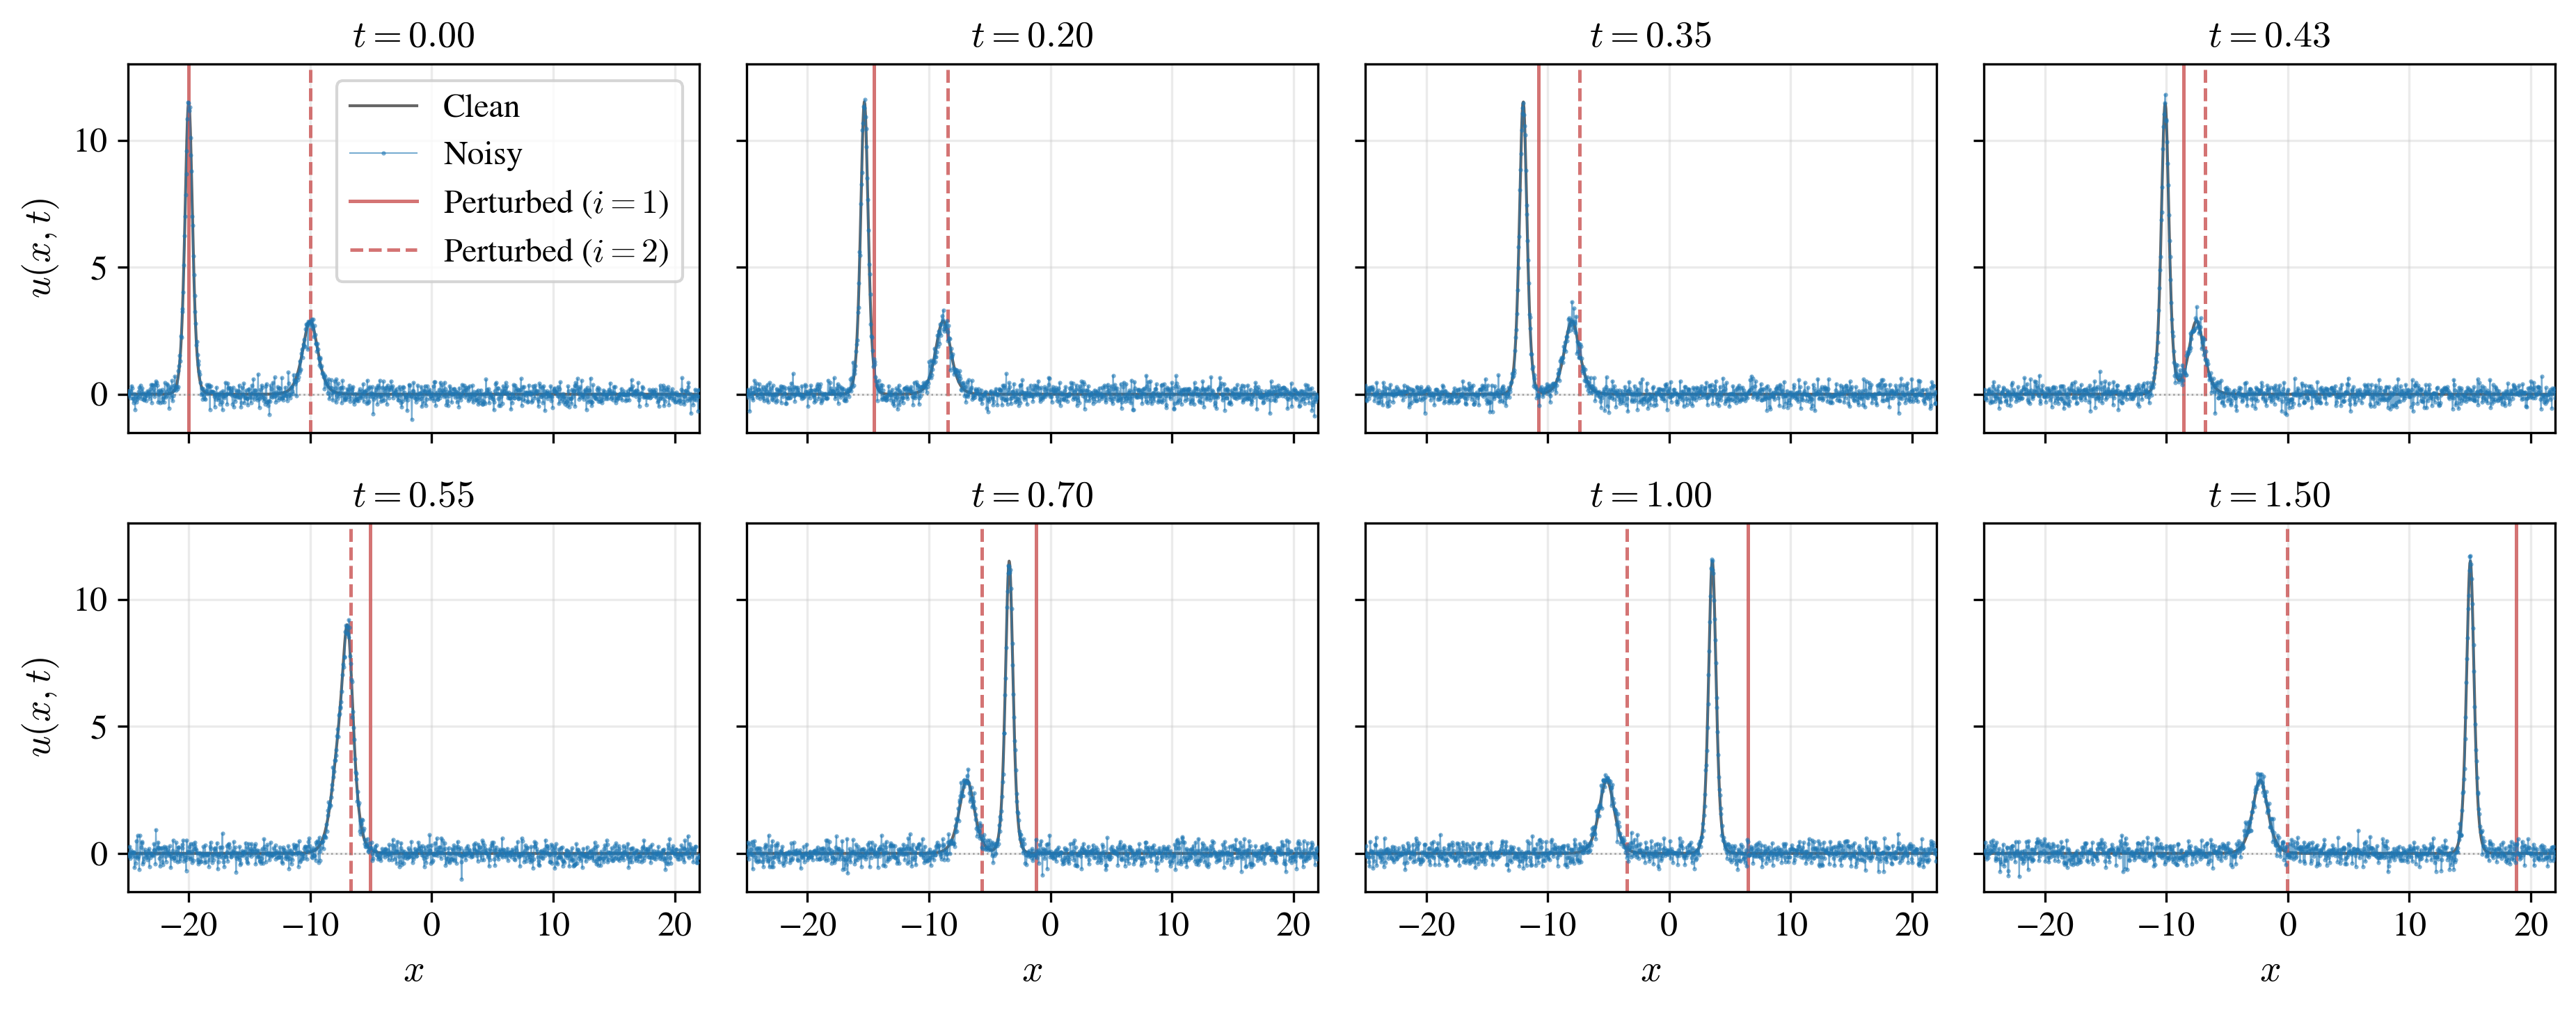

In [32]:
# Snapshots of the unperturbed collision (clean vs noisy) with perturbed peak markers
snapshot_times = [0.0, 0.2, 0.35, 0.43, 0.55, 0.7, 1.0, 1.5]

xlim = (-25, 22)
ylim = (-1.5, 13)
clean_kw = dict(color="k", lw=1.0, zorder=2, alpha=0.6)
noisy_kw = dict(color="C0", lw=0.5, ms=1, alpha=0.6, zorder=3)

fig, axes = plt.subplots(2, 4, figsize=(12.5, 5.0), sharex=True, sharey=True)

for ax, t_snap in zip(axes.flat, snapshot_times):
    j = int(np.argmin(np.abs(t_coll - t_snap)))
    ax.plot(x_coll, u_coll[j], label="Clean", **clean_kw)
    ax.plot(x_coll, u_coll_noisy[j], '.-', label="Noisy", **noisy_kw)
    ax.axvline(coll_peak_x1[j], color="indianred", ls="-", lw=1.2, alpha=0.85, label=r"Perturbed ($i=1$)")
    ax.axvline(coll_peak_x2[j], color="indianred", ls="--", lw=1.2, alpha=0.85, label=r"Perturbed ($i=2$)")
    ax.axhline(0, color="gray", lw=0.6, ls=":", alpha=0.7)
    ax.set_title(rf"$t = {t_coll[j]:.2f}$", fontsize=13)
    ax.grid(True, alpha=0.3, color="silver")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

for ax in axes[-1]:
    ax.set_xlabel(r"$x$", fontsize=13)
for ax in axes[:, 0]:
    ax.set_ylabel(r"$u(x,t)$", fontsize=13)

axes[0, 0].legend(fontsize=11.5, loc="upper right")

plt.tight_layout()
plt.show()

#### **FIGURE 3**

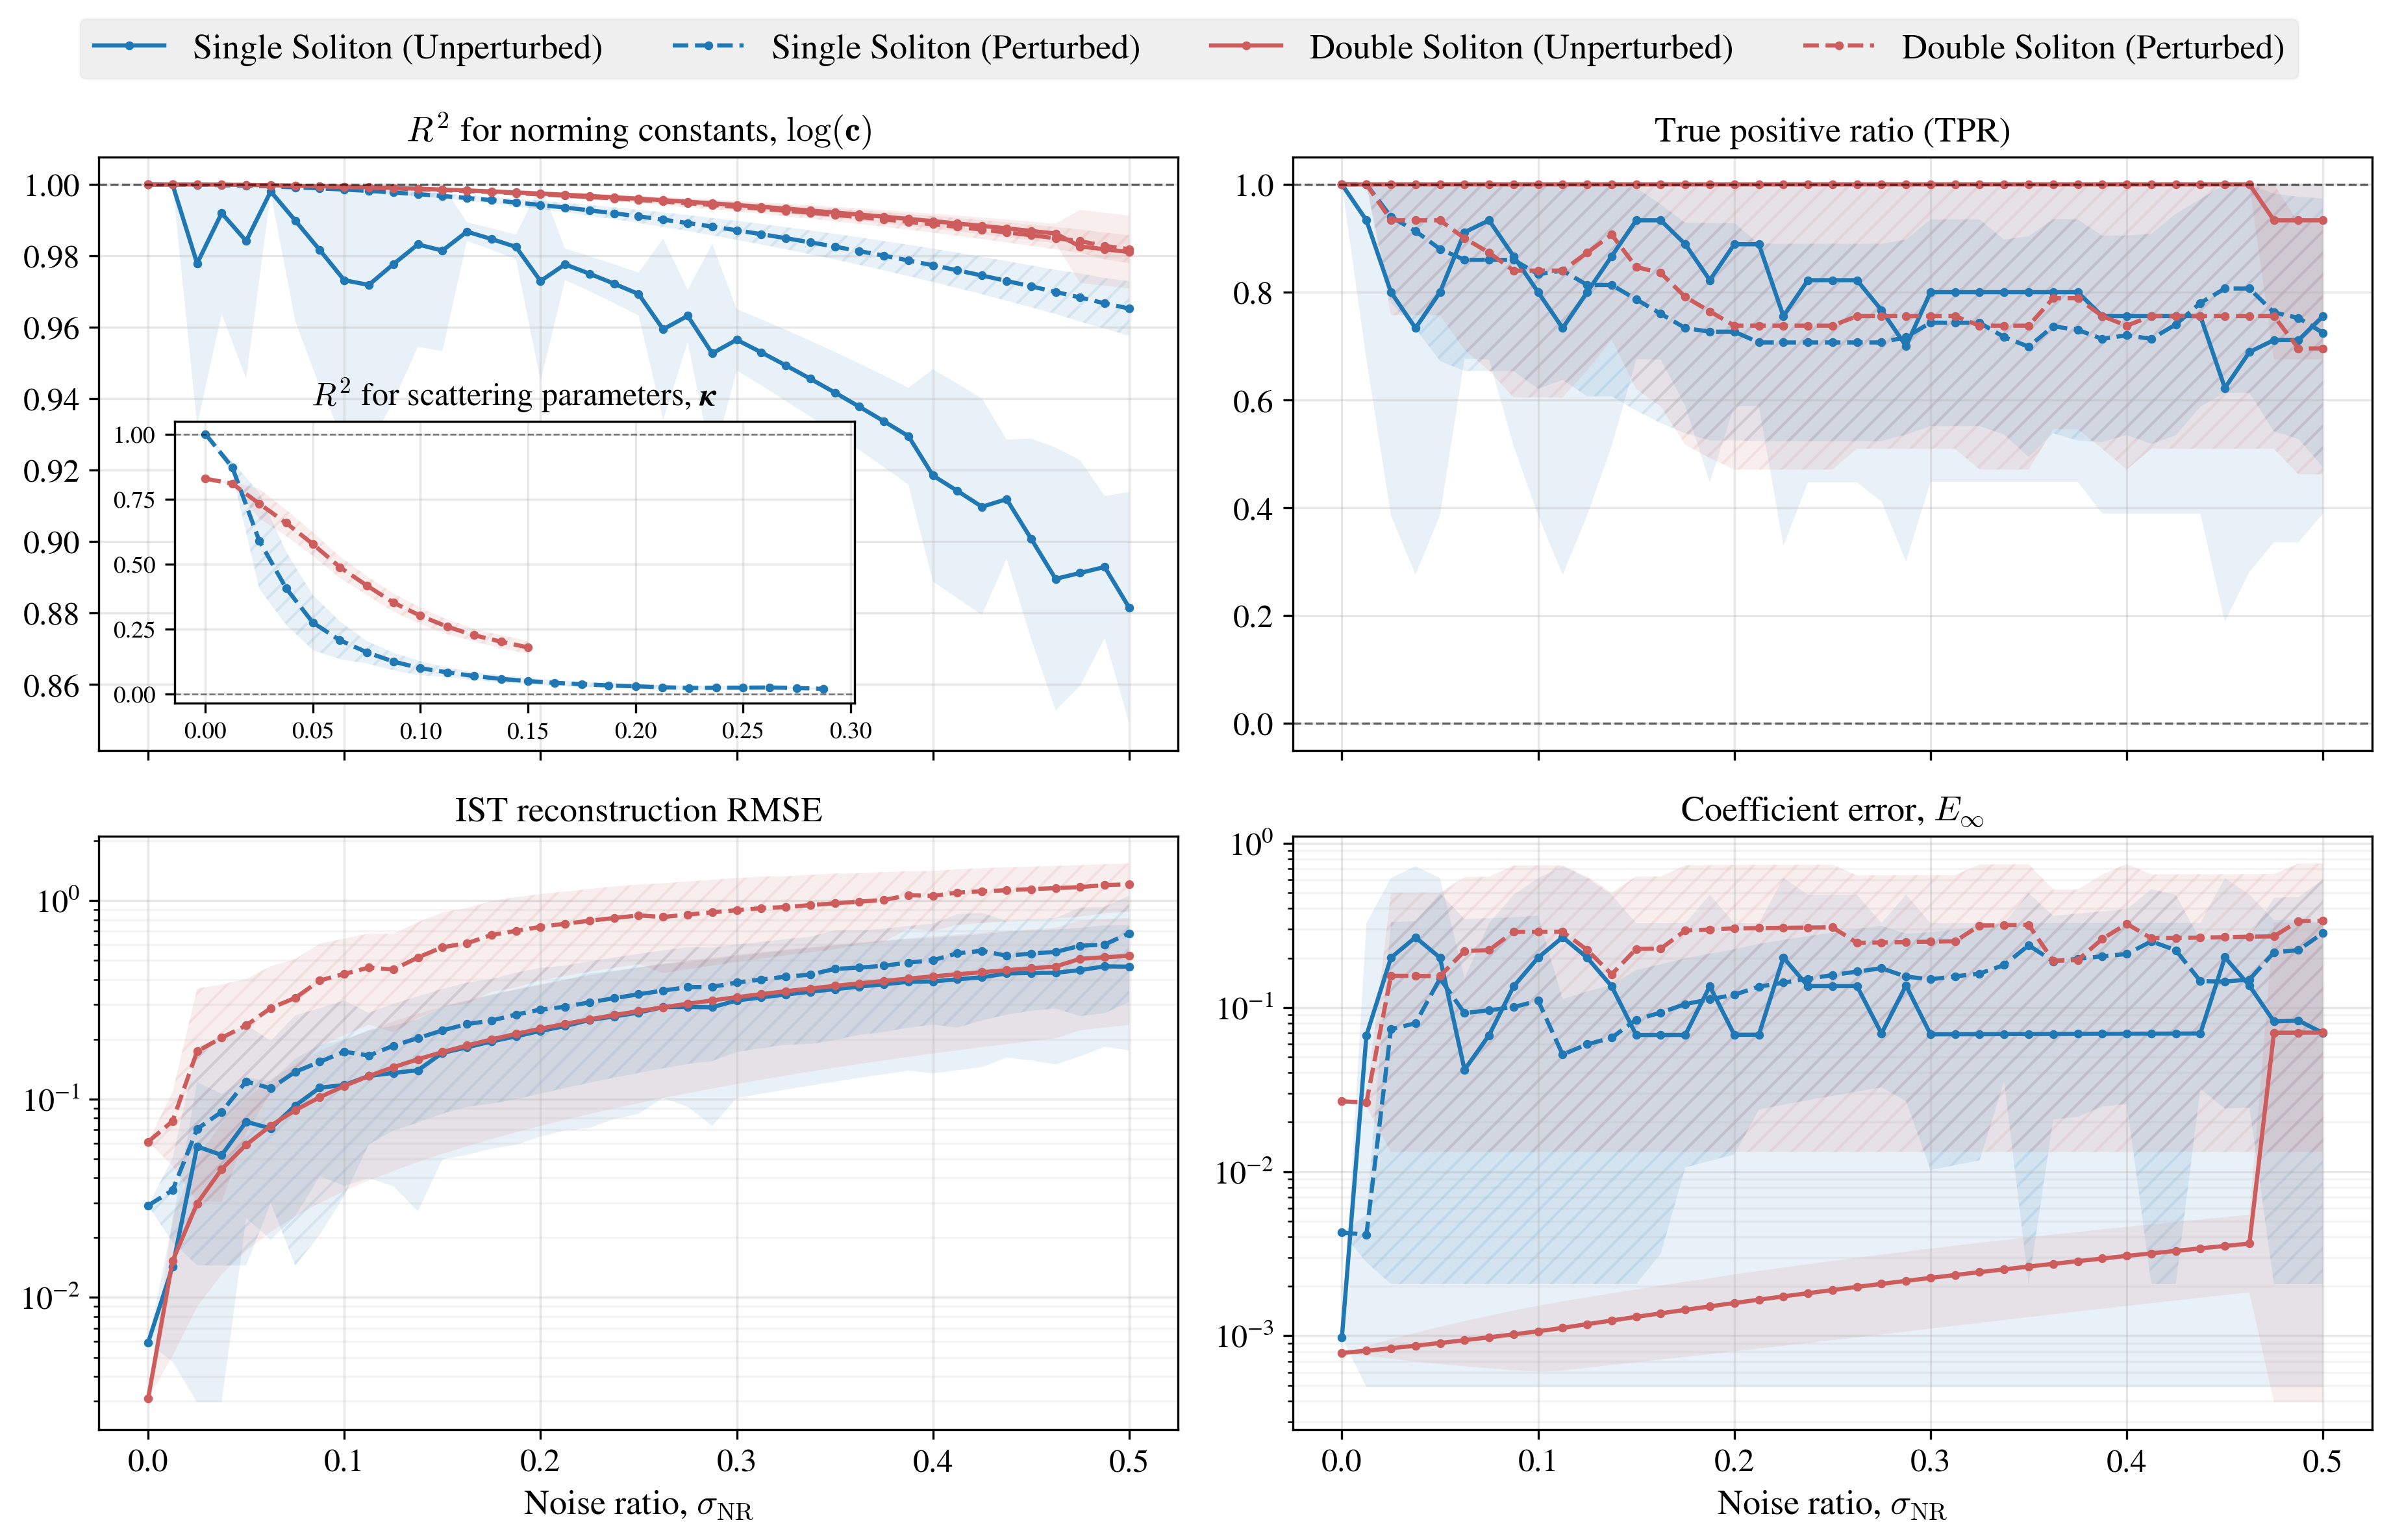

In [138]:
import numpy as np
import matplotlib.pyplot as plt
import noise_sweep

rows = noise_sweep.load_results("outputs/noise_sweep_results.jsonl")

case_order = ["single_soliton", "single_soliton_perturbed", "two_soliton", "two_soliton_perturbed"]
case_labels = {
    "single_soliton": "Single Soliton (Unperturbed)",
    "single_soliton_perturbed": "Single Soliton (Perturbed)",
    "two_soliton": "Double Soliton (Unperturbed)",
    "two_soliton_perturbed": "Double Soliton (Perturbed)",
}
#case_colors = {"single_soliton": "C0", "single_soliton_perturbed": "C0", "two_soliton": "C1", "two_soliton_perturbed": "C1"}
case_colors = {"single_soliton": "C0", "single_soliton_perturbed": "C0", "two_soliton": "indianred", "two_soliton_perturbed": "indianred"}
case_styles = {"single_soliton": ".-", "single_soliton_perturbed": ".--", "two_soliton": ".-", "two_soliton_perturbed": ".--"}
#case_styles = {"single_soliton": "-", "single_soliton_perturbed": "--", "two_soliton": "-", "two_soliton_perturbed": "--"}
case_hatches = {"single_soliton": None, "single_soliton_perturbed": "///", "two_soliton": None, "two_soliton_perturbed": "///"}


def plot_metric(ax, value_fn, logy=False, clip=None, cases=case_order):
    for case in cases:
        noise, mean, std = noise_sweep.aggregate_metric(rows, case, value_fn)
        if len(noise) == 0:
            continue
        color = case_colors[case]
        ax.plot(noise, mean, case_styles[case], ms=4.5, color=color, lw=1.55, label=case_labels[case])
        #ax.plot(noise, mean, case_styles[case], color=color, lw=1.7, label=case_labels[case])
        lo, hi = mean - std, mean + std
        if clip is not None:
            cl, ch = clip
            if cl is not None:
                lo = np.maximum(lo, cl)
            if ch is not None:
                hi = np.minimum(hi, ch)
        if logy:
            lo = np.maximum(lo, mean.min()*0.5)
        #ax.fill_between(noise, lo, hi, facecolor=color, alpha=0.18, linewidth=0)
        ax.fill_between(noise, lo, hi, facecolor=color, alpha=0.1, linewidth=0)
        if case_hatches[case]:
            #ax.fill_between(noise, lo, hi, facecolor="none", edgecolor=color, hatch=case_hatches[case], linewidth=0, alpha=0.45)
            ax.fill_between(noise, lo, hi, facecolor="none", edgecolor=color, hatch=case_hatches[case], linewidth=0, alpha=0.1)
    if logy:
        ax.set_yscale("log")
        ax.grid(True, which="minor", axis="y", alpha=0.15)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(12.5,7.6), sharex=True)

ax = axes[0,0]
plot_metric(ax, lambda r: r["R2"]["logc"], clip=(None, 1.0))
ax.axhline(1.0, color="k", lw=0.8, ls="--", alpha=0.6)
ax.set_title(r"$R^2$ for norming constants, $\log(\mathbf{c})$", fontsize=13)
#ax.set_xlabel(r"noise ratio $\sigma_{\rm NR}$", fontsize=13)

# axin = ax.inset_axes([0.11, 0.13, 0.45, 0.45])
axin = ax.inset_axes([0.07, 0.08, 0.63, 0.475])
plot_metric(axin, lambda r: r["R2"]["kappa"], clip=(None, 1.0), cases=["single_soliton_perturbed", "two_soliton_perturbed"])
axin.axhline(1.0, color="k", lw=0.6, ls="--", alpha=0.5)
axin.axhline(0.0, color="k", lw=0.6, ls="--", alpha=0.5)
# axin.set_title(r"$R^2$ of $\kappa$ eq. (perturbed)", fontsize=9)
# axin.tick_params(labelsize=8)
axin.set_title(r"$R^2$ for scattering parameters, $\boldsymbol{\kappa}$", fontsize=12)
axin.tick_params(labelsize=9)

ax = axes[0,1]
plot_metric(ax, lambda r: r["TPR"], clip=(0.0, 1.0))
ax.axhline(1.0, color="k", lw=0.8, ls="--", alpha=0.6)
ax.axhline(0.0, color="k", lw=0.8, ls="--", alpha=0.6)
ax.set_ylim(-0.05, 1.05)
ax.set_title(r"True positive ratio (TPR)", fontsize=13)

ax = axes[1,0]
plot_metric(ax, lambda r: r["RMSE_IST"], logy=True)
ax.set_title(r"IST reconstruction RMSE", fontsize=13)
ax.set_xlabel(r"Noise ratio, $\sigma_{\rm NR}$", fontsize=13)

ax = axes[1,1]
plot_metric(ax, lambda r: r["E_inf"], logy=True)
ax.set_title(r"Coefficient error, $E_\infty$", fontsize=13)
ax.set_xlabel(r"Noise ratio, $\sigma_{\rm NR}$", fontsize=13)

handles, labels = axes[0,0].get_legend_handles_labels()
#fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.03), frameon=False, fontsize=12)
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05), frameon=True, facecolor="gray", framealpha=0.12, fontsize=13)

plt.tight_layout()
plt.show()